In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score

from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.regularizers import l1_l2
from keras.optimizers import Adam, RMSprop, SGD
from keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score

In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 5.1 MB/s eta 0:00:00


In [3]:
import optuna

In [4]:
df = pd.read_csv(r"/content/LI-Small_Trans_new.csv")
df

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:02,70,10042B660,22661,805F7F2B0,70831.64,US Dollar,70831.64,US Dollar,Cash,1
1,2022/09/01 00:19,70,10042B660,212996,80609B4C0,33705.47,US Dollar,33705.47,US Dollar,Cash,1
2,2022/09/01 00:01,70,10042B660,11305,807861770,1097976.27,US Dollar,1097976.27,US Dollar,Cash,1
3,2022/09/01 00:00,11968,815630C40,249349,815635220,892.33,US Dollar,892.33,US Dollar,ACH,1
4,2022/09/01 00:25,70,10042B660,11968,816F93AF0,1808.14,US Dollar,1808.14,US Dollar,Cheque,1
...,...,...,...,...,...,...,...,...,...,...,...
72765,2022/09/05 12:55,113,8000B2F90,19,810BDE890,3707894.61,Mexican Peso,3707894.61,Mexican Peso,Cheque,0
72766,2022/09/02 23:07,12204,8061A7620,21828,80B1EA2C0,4454.01,US Dollar,4454.01,US Dollar,Cheque,0
72767,2022/09/06 11:24,23486,80982B510,25892,80AC15310,19211.82,Rupee,19211.82,Rupee,Cash,0
72768,2022/09/02 17:29,70,10042B660,140797,810023350,5392.93,US Dollar,5392.93,US Dollar,Cheque,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

,0
Timestamp,0
From Bank,0
Account,0
To Bank,0
Account.1,0
Amount Received,0
Receiving Currency,0
Amount Paid,0
Payment Currency,0
Payment Format,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72770 entries, 0 to 72769
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Timestamp           72770 non-null  object 
 1   From Bank           72770 non-null  int64  
 2   Account             72770 non-null  object 
 3   To Bank             72770 non-null  int64  
 4   Account.1           72770 non-null  object 
 5   Amount Received     72770 non-null  float64
 6   Receiving Currency  72770 non-null  object 
 7   Amount Paid         72770 non-null  float64
 8   Payment Currency    72770 non-null  object 
 9   Payment Format      72770 non-null  object 
 10  Is Laundering       72770 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 6.1+ MB


In [8]:
df.head(1)

,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022/09/01 00:02,70,10042B660,22661,805F7F2B0,70831.64,US Dollar,70831.64,US Dollar,Cash,1


In [9]:
df["From Bank"] = df["From Bank"].astype("object")
df["To Bank"] = df["To Bank"].astype("object")

In [10]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Hour"] = df["Timestamp"].dt.hour
df["Week"] = df["Timestamp"].dt.dayofweek

In [11]:
df["Amount_Diff"] = (df["Amount Received"]-df["Amount Paid"])
df["Payment_mismatch"]= (df["Receiving Currency"] != df["Payment Currency"]).astype('int')

In [12]:
from_bank_freq = df["From Bank"].value_counts(normalize = True)
to_bank_freq = df["To Bank"].value_counts(normalize = True)
df["From_bank_freq"] = df["From Bank"].map(from_bank_freq)
df["To_Bank_freq"] = df["To Bank"].map(to_bank_freq)

In [13]:
df.drop(columns = ["From Bank","To Bank","Account.1","Account","Timestamp"],inplace = True)

In [14]:
X = df.drop(columns = ["Is Laundering"])
y = df["Is Laundering"]

In [15]:
X_train_full , X_test,y_train_full,y_test = train_test_split(X,y,test_size=0.2,random_state=21,stratify=y)

In [16]:
X_train,X_val,y_train,y_val = train_test_split(X_train_full,y_train_full,test_size=0.2,random_state=21,stratify=y_train_full)

In [17]:
num_cols = X.select_dtypes(exclude = "object").columns
cat_cols = X.select_dtypes(include = "object").columns

In [18]:
preprocessor = ColumnTransformer([("Scaling",MinMaxScaler(),num_cols),
                                  ("Encoding",OneHotEncoder(drop = "first",handle_unknown="ignore"),cat_cols)],
                                 remainder = "drop")

In [19]:
X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

In [20]:
model = Sequential([Input(shape=(X_train_t.shape[1],)),
                    Dense(32,activation="relu"),
                    Dense(64,activation="relu"),
                    Dense(1,activation="sigmoid")])

In [21]:
model.compile(optimizer="Adam",loss = "binary_crossentropy",metrics = ["accuracy"])

In [22]:
early = EarlyStopping(monitor = "val_loss",patience = 5 , restore_best_weights=True)

In [23]:
model.fit(X_train_t,y_train,
          epochs = 50,
          validation_data=(X_val_t,y_val),
          batch_size=256,
          callbacks=[early],
          verbose = 2)

Epoch 1/50
182/182 - 3s - 18ms/step - accuracy: 0.9424 - loss: 0.2274 - val_accuracy: 0.9510 - val_loss: 0.1481
Epoch 2/50
182/182 - 2s - 11ms/step - accuracy: 0.9510 - loss: 0.1302 - val_accuracy: 0.9510 - val_loss: 0.1219
Epoch 3/50
182/182 - 2s - 11ms/step - accuracy: 0.9520 - loss: 0.1188 - val_accuracy: 0.9526 - val_loss: 0.1180
Epoch 4/50
182/182 - 2s - 11ms/step - accuracy: 0.9531 - loss: 0.1173 - val_accuracy: 0.9526 - val_loss: 0.1174
Epoch 5/50
182/182 - 2s - 13ms/step - accuracy: 0.9532 - loss: 0.1163 - val_accuracy: 0.9526 - val_loss: 0.1167
Epoch 6/50
182/182 - 1s - 8ms/step - accuracy: 0.9533 - loss: 0.1160 - val_accuracy: 0.9526 - val_loss: 0.1172
Epoch 7/50
182/182 - 2s - 8ms/step - accuracy: 0.9538 - loss: 0.1152 - val_accuracy: 0.9534 - val_loss: 0.1163
Epoch 8/50
182/182 - 3s - 15ms/step - accuracy: 0.9538 - loss: 0.1149 - val_accuracy: 0.9527 - val_loss: 0.1161
Epoch 9/50
182/182 - 2s - 10ms/step - accuracy: 0.9543 - loss: 0.1146 - val_accuracy: 0.9531 - val_loss: 0

In [24]:
y_pred = np.where(model.predict(X_test_t)>0.5,1,0)

455/455 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [25]:
accuracy_score(y_pred,y_test)

0.9543080939947781

In [26]:
smote = SMOTE()
X_train_res,y_train_res = smote.fit_resample(X_train_t,y_train)

In [27]:
def objective(trial):
    lr_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    n_layers = trial.suggest_int('n_layers', 1, 4)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])
    activation = trial.suggest_categorical('activation', ['tanh', 'relu'])
    batch_size1 = trial.suggest_categorical('batch_size', [32, 64, 128, 256, 512])

    model = Sequential()
    model.add(Input(shape=(X_train_res.shape[1],)))
    for i in range(n_layers):
        units = trial.suggest_int(f'units{i}', 8, 96)
        dropout = trial.suggest_float(f'dropout{i}', 0.0, 0.5)
        reg = trial.suggest_float(f'reg{i}', 1e-5, 1e-2, log=True)
        model.add(Dense(units, activation=activation, kernel_regularizer=l1_l2(l1=reg, l2=reg)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))

    opt_map = {
        'Adam': Adam(learning_rate=lr_rate),
        'RMSprop': RMSprop(learning_rate=lr_rate),
        'SGD': SGD(learning_rate=lr_rate)
    }
    model.compile(optimizer=opt_map[optimizer_name], loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.Recall(name='recall')])

    es = EarlyStopping(monitor='val_recall', mode='max', patience=5, restore_best_weights=True)
    history = model.fit(
        X_train_res, y_train_res,
        epochs=30, batch_size=batch_size1,
        validation_data=(X_val_t, y_val),   # validation set, NOT test
        callbacks=[es], verbose=0
    )
    return max(history.history['val_recall'])

In [28]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=21))
study.optimize(objective, n_trials=5, show_progress_bar=True)

[I 2026-06-27 13:26:41,659] A new study created in memory with name: no-name-4c5aa527-bfd9-424f-814d-10d082a88c3f


  0%|          | 0/5 [00:00<?, ?it/s]

[I 2026-06-27 13:26:59,941] Trial 0 finished with value: 0.9719298481941223 and parameters: {'learning_rate': 0.0001251554487151282, 'n_layers': 2, 'optimizer': 'Adam', 'activation': 'relu', 'batch_size': 512, 'units0': 19, 'dropout0': 0.08906233077974918, 'reg0': 0.00030746001885481724, 'units1': 84, 'dropout1': 0.37947191775605715, 'reg1': 0.008155589837765905}. Best is trial 0 with value: 0.9719298481941223.
[I 2026-06-27 13:28:24,262] Trial 1 finished with value: 0.9859648942947388 and parameters: {'learning_rate': 0.00330069279804087, 'n_layers': 2, 'optimizer': 'RMSprop', 'activation': 'relu', 'batch_size': 32, 'units0': 37, 'dropout0': 0.23007016689648802, 'reg0': 0.0004296403664910425, 'units1': 27, 'dropout1': 0.39993416346948824, 'reg1': 0.001513747182776292}. Best is trial 1 with value: 0.9859648942947388.
[I 2026-06-27 13:29:18,971] Trial 2 finished with value: 0.9964912533760071 and parameters: {'learning_rate': 0.004995574347086988, 'n_layers': 2, 'optimizer': 'RMSprop', 

In [29]:
study.best_params

{'learning_rate': 0.004995574347086988,
 'n_layers': 2,
 'optimizer': 'RMSprop',
 'activation': 'relu',
 'batch_size': 64,
 'units0': 78,
 'dropout0': 0.4438277186036015,
 'reg0': 0.00124905731421375,
 'units1': 48,
 'dropout1': 0.15295758239442775,
 'reg1': 0.0028857135238802138}

In [30]:
model  = Sequential()

# Input Layer
model.add(Input(shape=(X_train_res.shape[1],)))

# 1st hidden Layer

model.add(Dense(37,activation='relu',kernel_initializer='he_normal',kernel_regularizer=l1_l2(l1=0.0004296403664910425,l2 = 0.0004296403664910425)))
model.add(BatchNormalization())
model.add(Dropout(0.23007016689648802))

# 2nd layer

model.add(Dense(27,activation='relu',kernel_initializer='he_normal',kernel_regularizer=l1_l2(l1=0.001513747182776292,l2 =0.001513747182776292 )))
model.add(BatchNormalization())
model.add(Dropout(0.39993416346948824))

# Output layer

model.add(Dense(1,activation='sigmoid',kernel_initializer="glorot_uniform"))


In [31]:
model.compile(optimizer=RMSprop(learning_rate=0.00330069279804087), loss='binary_crossentropy',
                  metrics=["accuracy",tf.keras.metrics.Recall(name='recall')])

In [32]:
es = EarlyStopping(monitor='val_recall', mode='max', patience=5, restore_best_weights=True)

In [33]:
history = model.fit(
        X_train_res, y_train_res,
        epochs=30, batch_size=32,
        validation_data=(X_val_t, y_val),   # validation set, NOT test
        callbacks=[es], verbose=0
    )

In [34]:
y_pred=np.where(model.predict(X_test_t)>0.5,1,0)

455/455 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [35]:
accuracy_score(y_pred,y_test)

0.7887865878796207

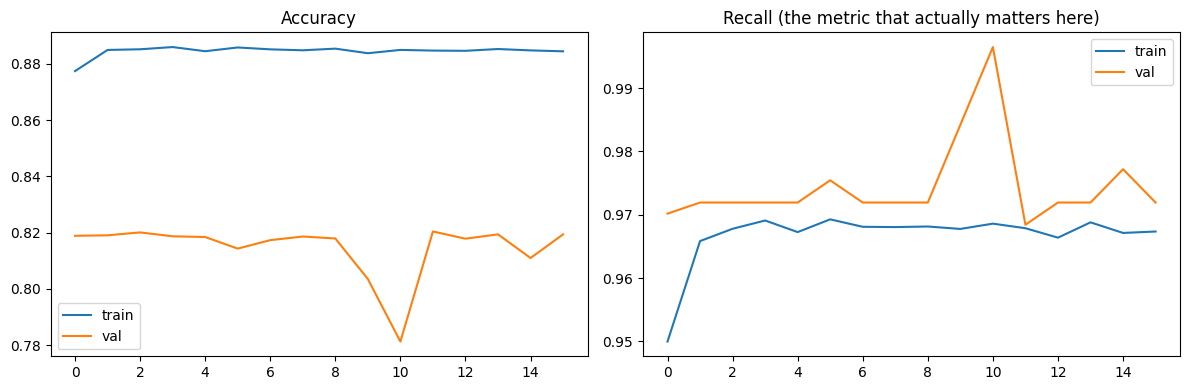

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy'); axes[0].legend()

axes[1].plot(history.history['recall'], label='train')
axes[1].plot(history.history['val_recall'], label='val')
axes[1].set_title('Recall (the metric that actually matters here)'); axes[1].legend()
plt.tight_layout()
plt.show()

In [37]:
# Training accuracy
y_pred_train = np.where(model.predict(X_train_res) > 0.5, 1, 0)
train_acc = accuracy_score(y_train_res, y_pred_train)

# Validation accuracy
y_pred_val = np.where(model.predict(X_val_t) > 0.5, 1, 0)
val_acc = accuracy_score(y_val, y_pred_val)

# Test accuracy
y_pred_test = np.where(model.predict(X_test_t) > 0.5, 1, 0)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")

2769/2769 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
364/364 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
455/455 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Train Accuracy      : 0.8833
Validation Accuracy : 0.7813
Test Accuracy       : 0.7888


In [38]:
# Mild OVerfit but good model

In [39]:
# Because your test set is imbalanced (original distribution, no SMOTE),
# a model predicting mostly class 0 can easily hit 82% accuracy while catching almost no laundering cases.

In [40]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      0.78      0.88     13841
           1       0.19      0.99      0.31       713

    accuracy                           0.79     14554
   macro avg       0.59      0.88      0.59     14554
weighted avg       0.96      0.79      0.85     14554



In [41]:
import pickle

with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

model.save('model.keras')
print("Saved preprocessor.pkl and model.keras")

Saved preprocessor.pkl and model.keras
